In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

Failed to import cupy.


In [15]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [95]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = np.nan                   # Magnification rate from input to objective
w_0 = np.nan                 # mm
alpha = np.arcsin(num_apt / n)

#10 microns
L_ffp = 0.050
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)



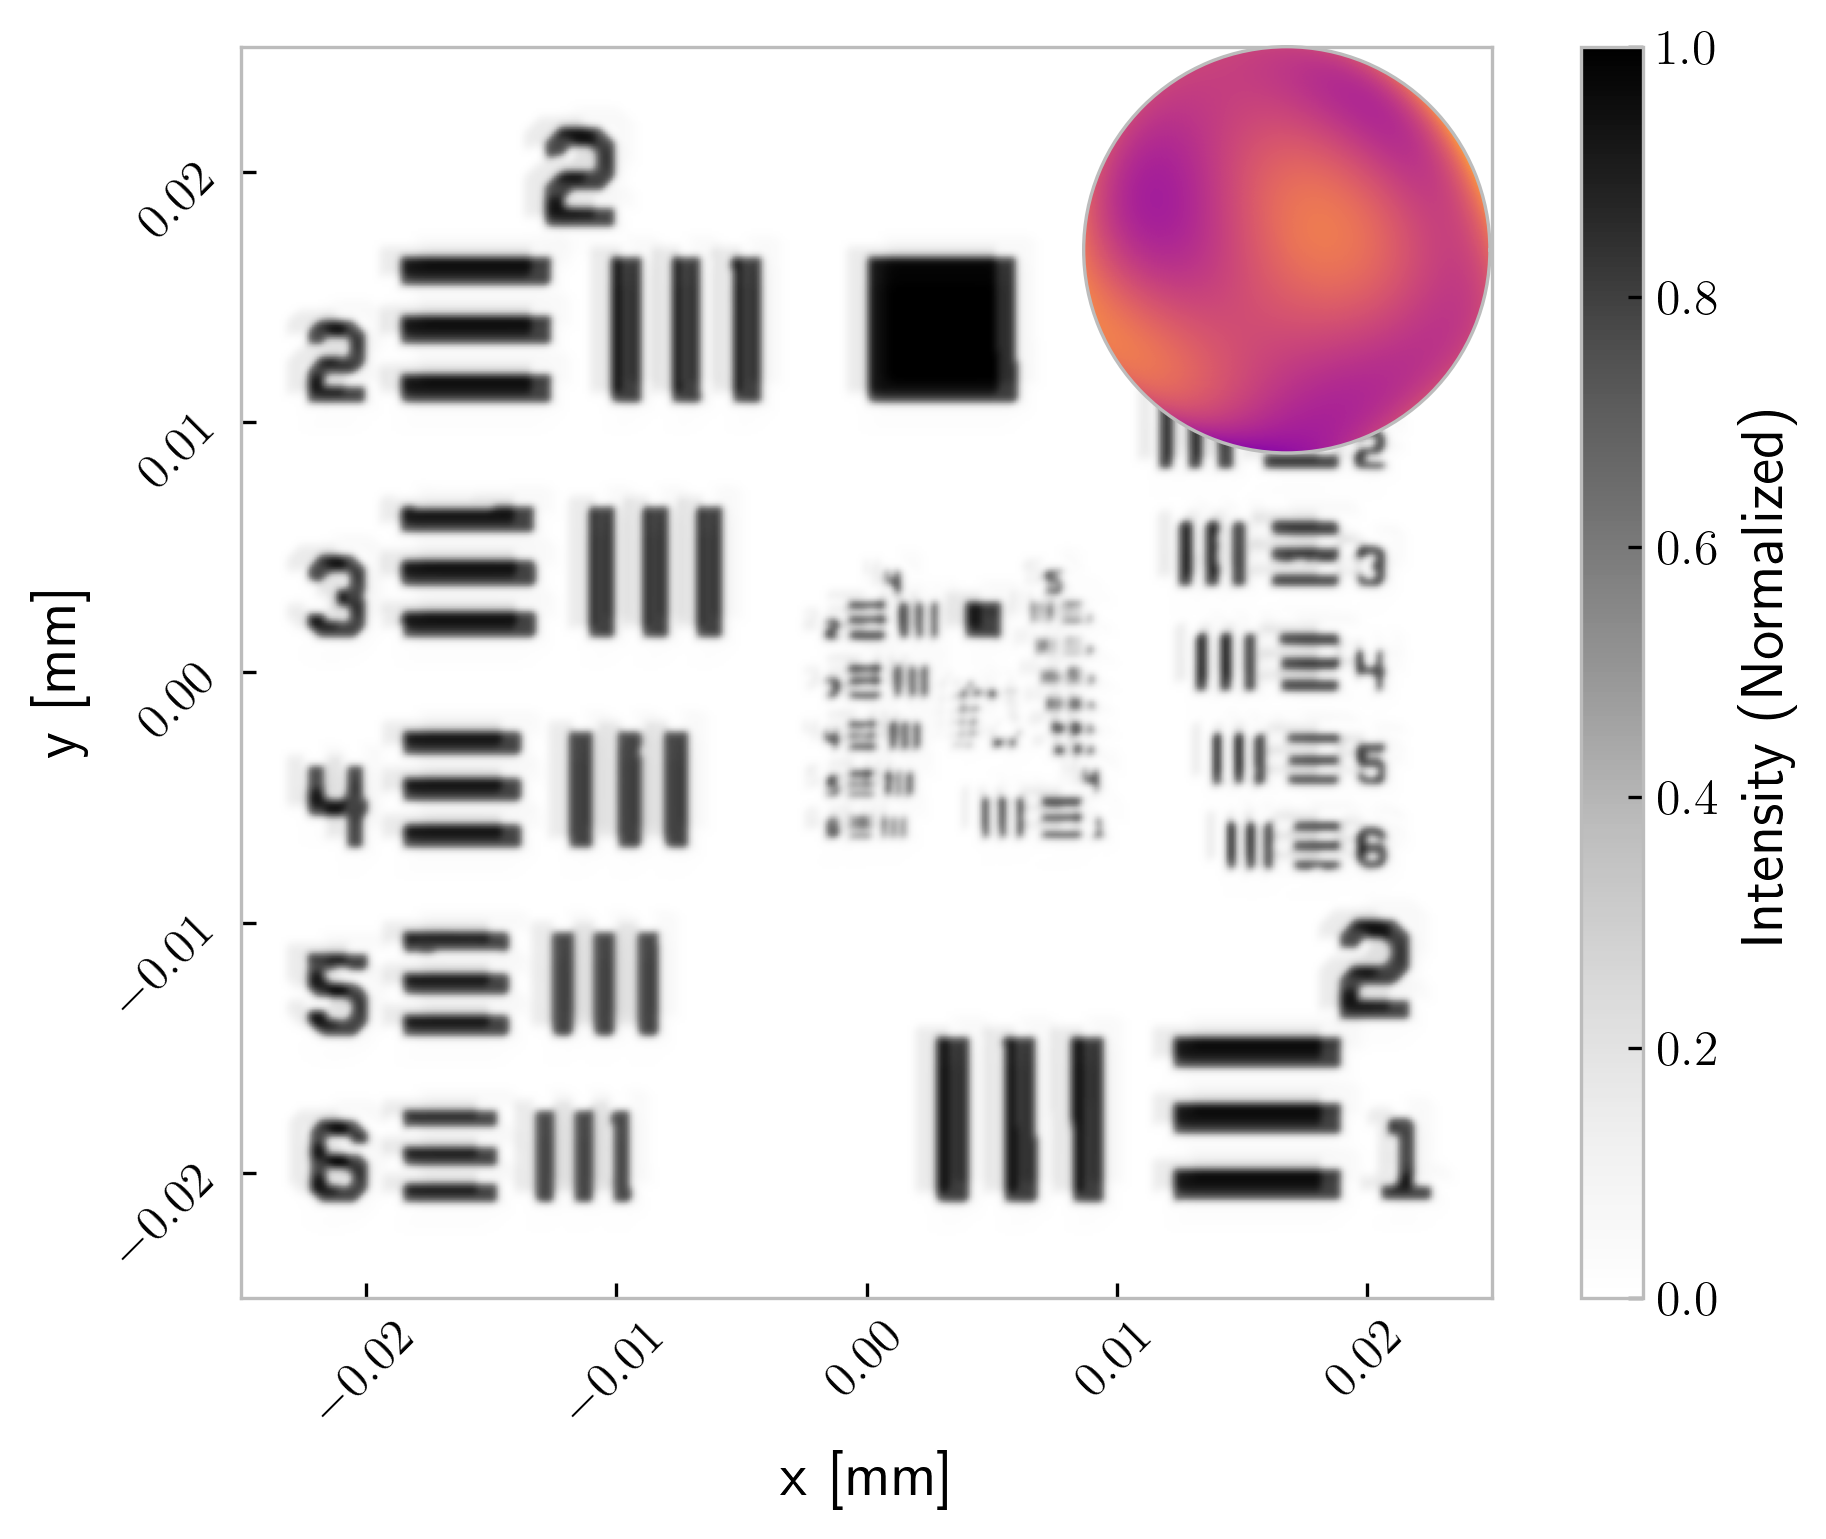

In [184]:
f =  np.flip(np.load("images/usaf_resolution.npy"), axis = 0)

rng = np.random.default_rng(10)
true_aberration = generate_johnson_aberration(1.0, alpha, rng)
d = forward_image(microscope, f, true_aberration)
composite_plot(x, y, d, true_aberration.construct_map(alpha), alpha)


In [185]:
bias_modes = [[-2,2], [0,2], [2,2]]
bias_strength = 2.0
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes] + [Aberration([m], [-bias_strength]) for m in bias_modes]
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])

modes_corrected = get_johnson_modes()

params = {
                "gamma": 1e-24,
                "J_tol": 0.001,
                "max_step": 0.05
            }

c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = False,
                                            log = False)

  8%|▊         | 8/100 [01:34<18:06, 11.81s/it]


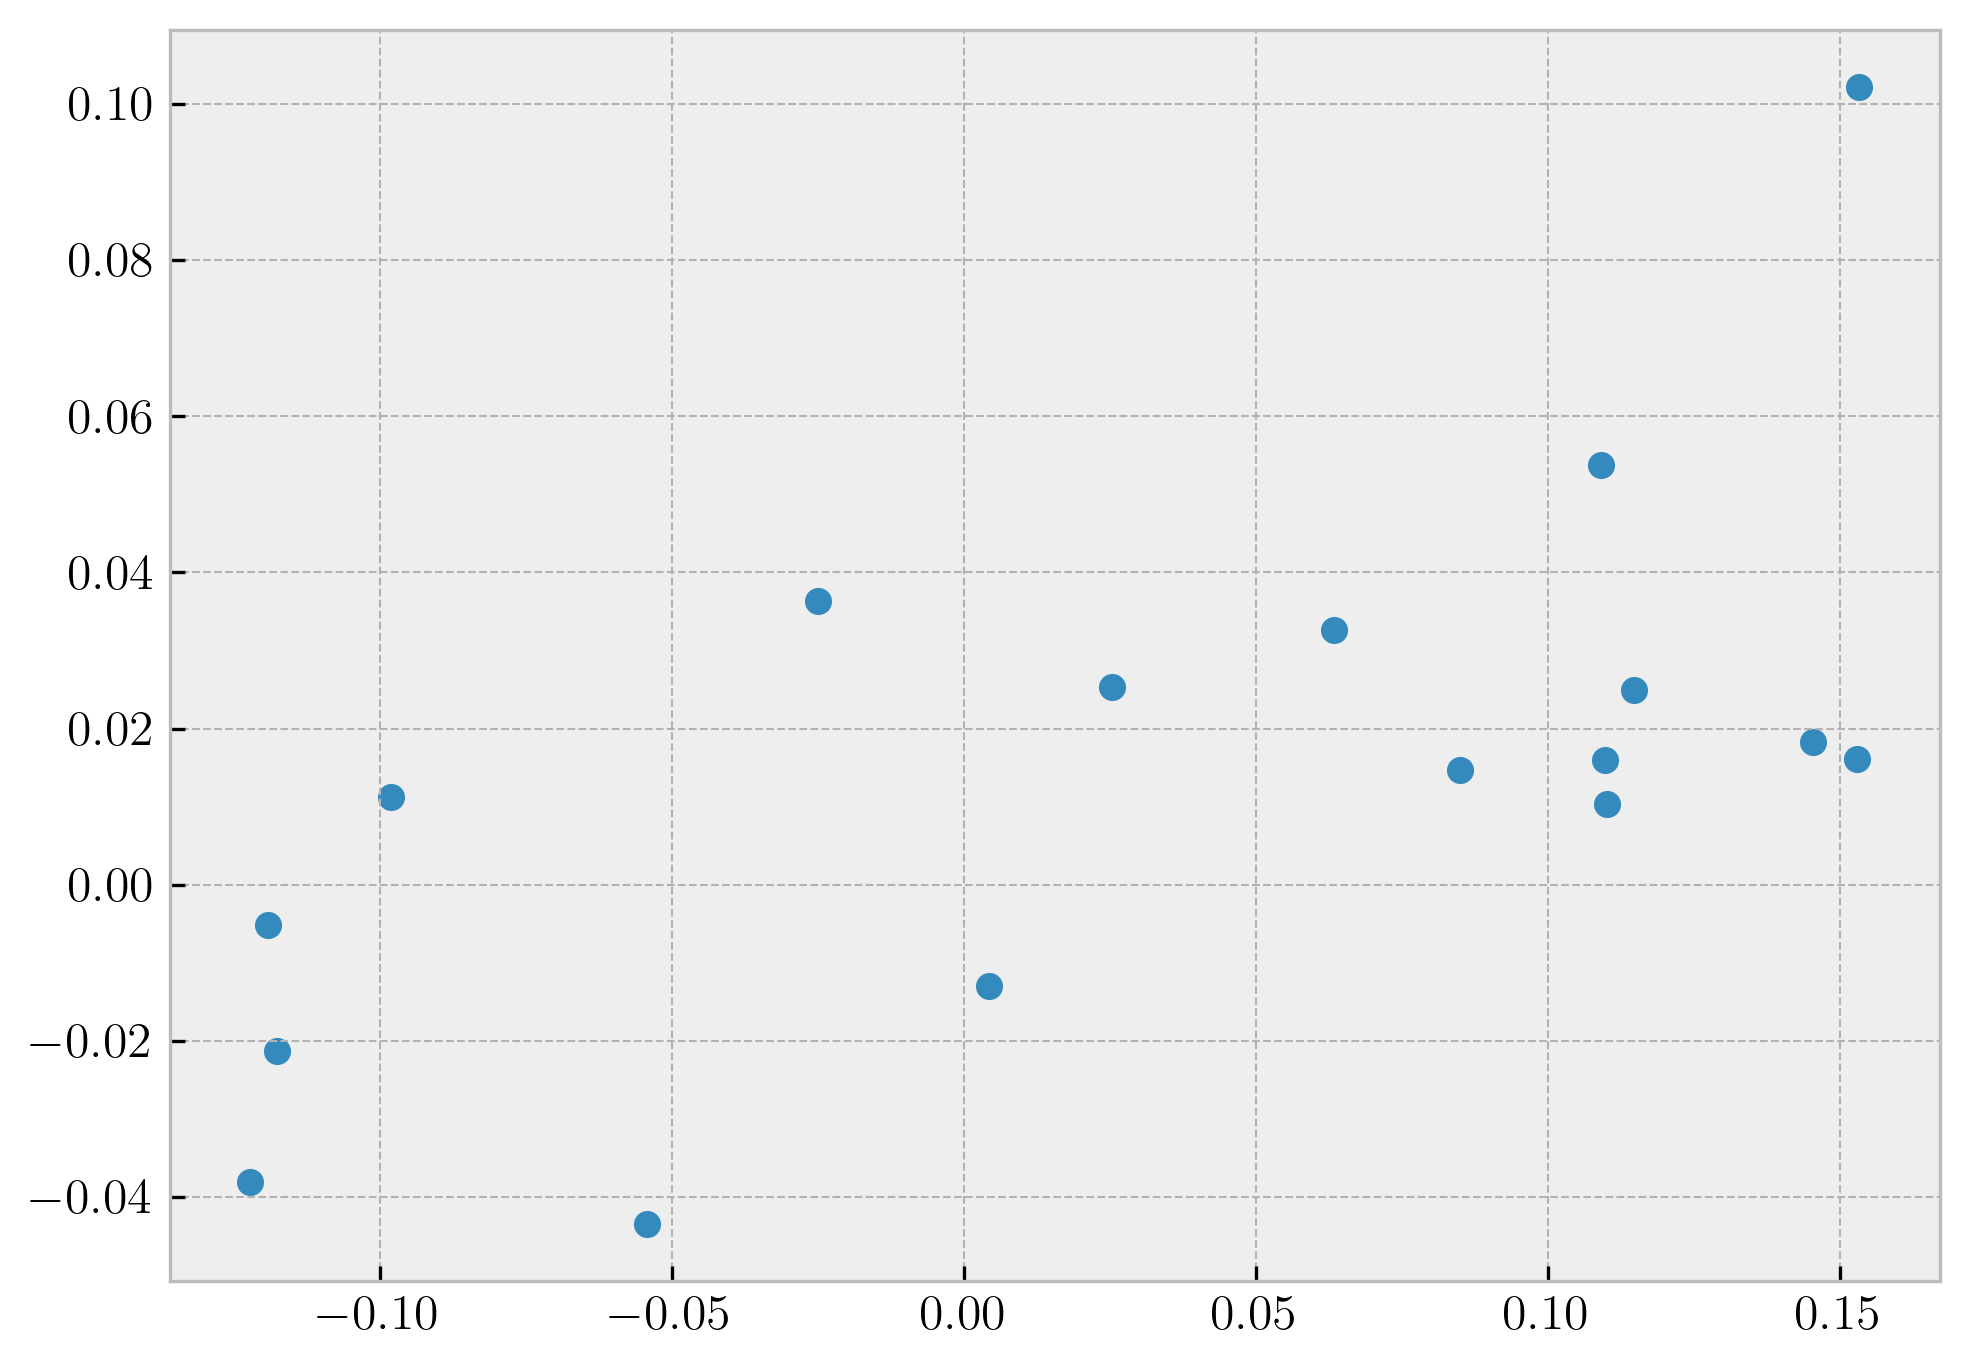

In [ ]:
plt.scatter(true_aberration.strengths, c_guess )

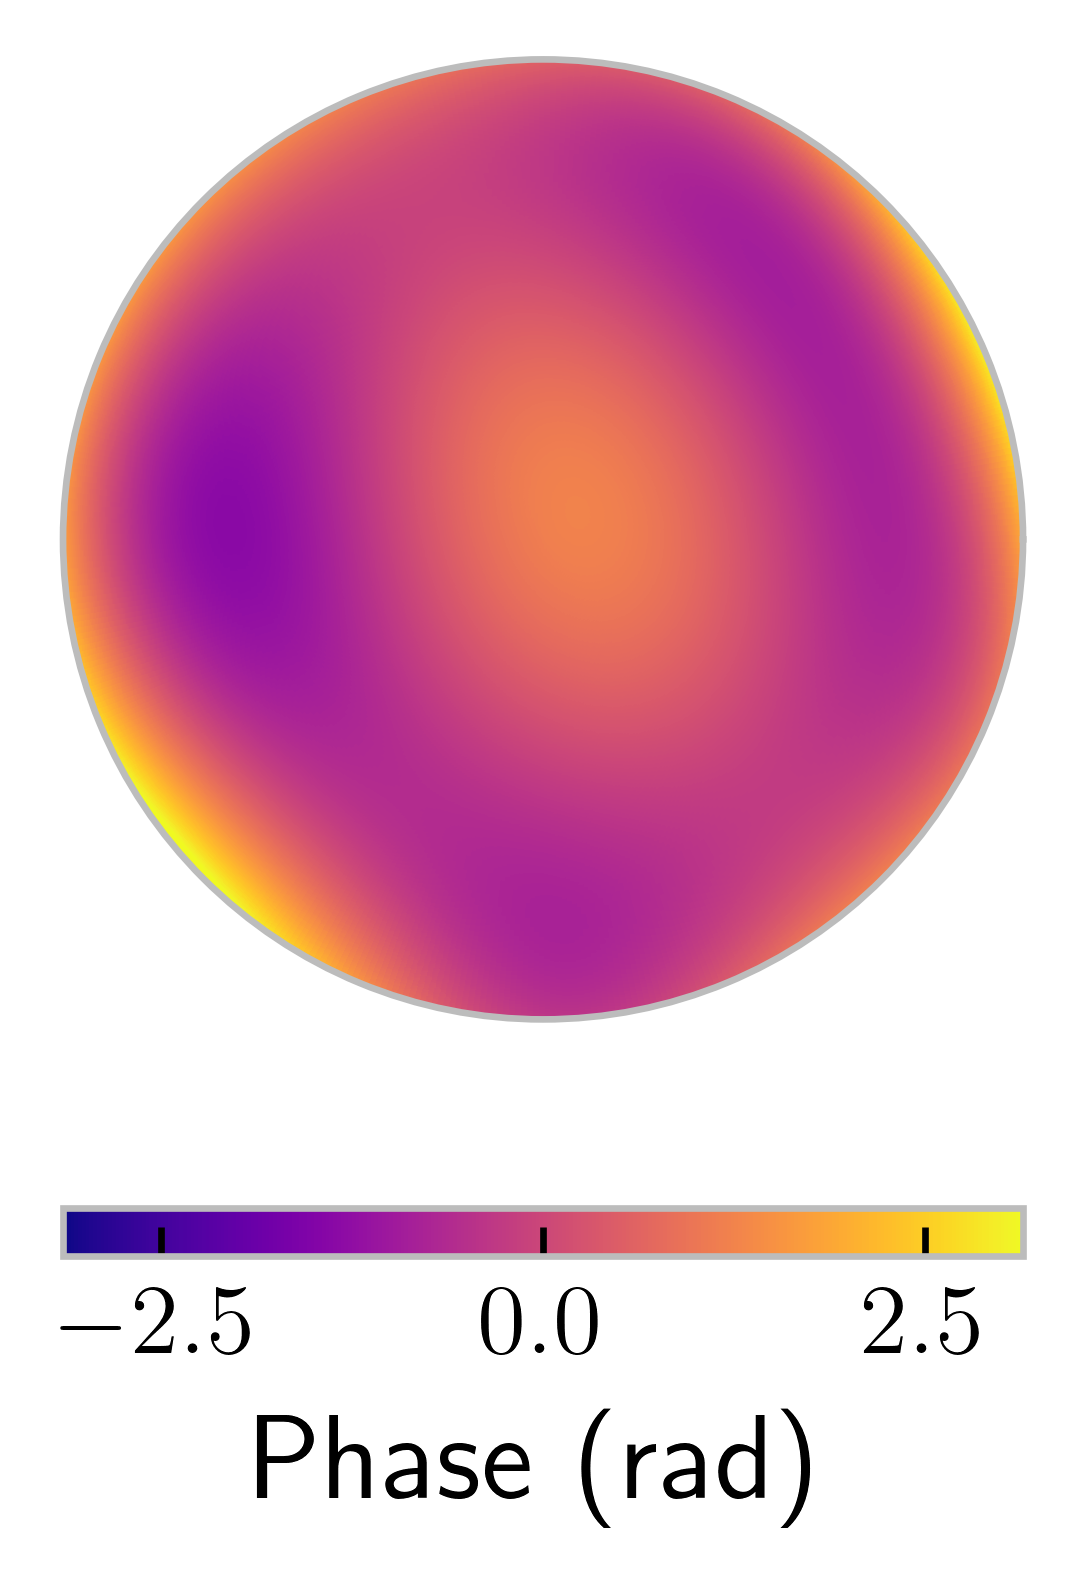

In [191]:
inferred_aberration = Aberration(modes_corrected, c_guess * 2)
zernike_plot(inferred_aberration.construct_map(alpha), alpha)

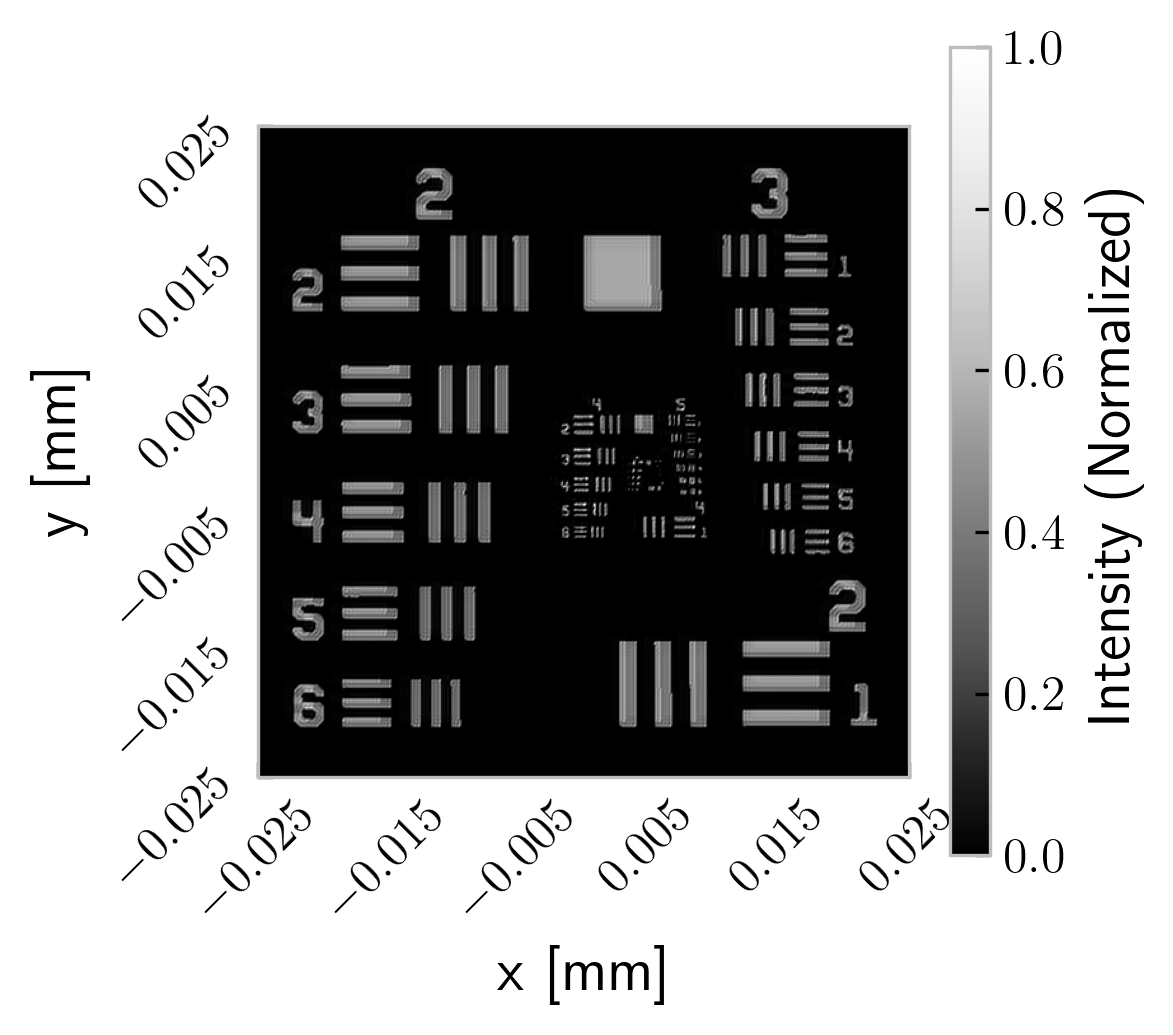

In [188]:
plot_intensity(x, y, np.real(np.fft.ifft2(F_guess))**2)

In [189]:
zernike_RMS(true_aberration - inferred_aberration, alpha)

np.float64(0.8078146489937149)

In [190]:
zernike_RMS(true_aberration, alpha)

np.float64(1.0)